In [1]:
using Plots,JLD2,LinearAlgebra

In [2]:
Nx=20
Ny=20
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.01
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [3]:
st=load("test.jld2")
   

Dict{String, Any} with 12 entries:
  "Eelec"          => -2.37756
  "spectrum"       => [-4.74, -4.74, -4.70378, -4.70378, -4.70378, -4.70378, -4…
  "max_record"     => 2.533e-5
  "average_record" => 1.61381e-5
  "orbital_id"     => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_id"      => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_coor"    => [-2.21776e-5, -2.06629e-5, -2.21776e-5, -2.06629e-5, -2.2…
  "FL"             => 1.64373
  "ave_npa"        => 500.0
  "E_total"        => -2.37756
  "Egap"           => 2.22045e-16
  "free_energy"    => -2.37773

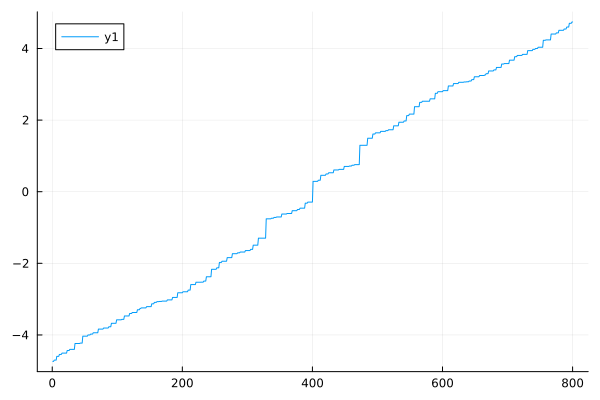

In [22]:
plot(sort(st["spectrum"]))

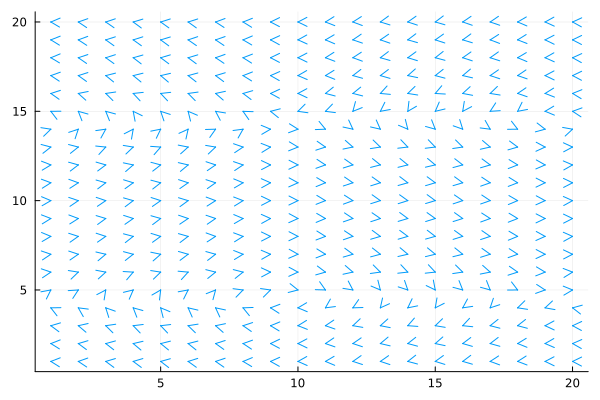

In [4]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [5]:
#savefig(p1,"quiverplot.png")

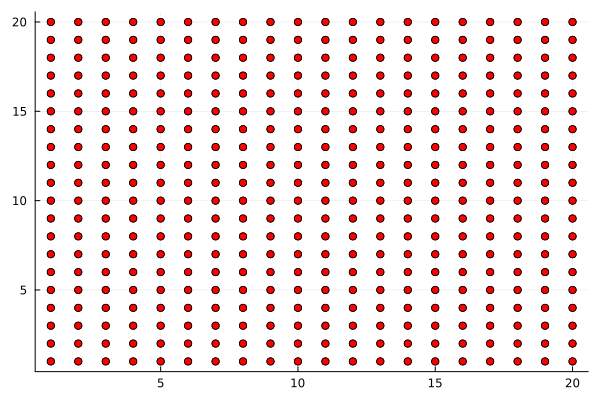

In [6]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [7]:
#savefig(p2,"atomplot.png")

In [8]:
sort(vec(dis_y)-vec(atom_y))

400-element Vector{Float64}:
 -6.5554765029673945e-6
 -6.5554765029673945e-6
 -6.5554765029673945e-6
 -6.555476502079216e-6
 -6.555476501191038e-6
 -6.555476501191038e-6
 -6.555476499414681e-6
 -6.555476499414681e-6
 -6.555476499414681e-6
 -6.555476499414681e-6
  ⋮
  6.561322287268467e-6
  6.561322287268467e-6
  6.5613222877125565e-6
  6.5613222888227796e-6
  6.561322289044824e-6
  6.561322290821181e-6
  6.561322290821181e-6
  6.561322290821181e-6
  6.561322290821181e-6

In [9]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

400-element Vector{Float64}:
  1.4142001892132647
  2.23605123393249
  2.236062765875242
  2.828417937667483
  3.162258506097783
  3.1622770284446857
  3.605540493312754
  3.6055488088368217
  4.123086941880773
  4.1231071143248785
  ⋮
 26.17248879495973
 26.24879097232803
 26.248797598153573
 26.870040087429576
 26.907230008686255
 26.90723268218589
 27.586211619437247
 27.58621221178787
 28.284254976118813

In [10]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

15.951735278369142

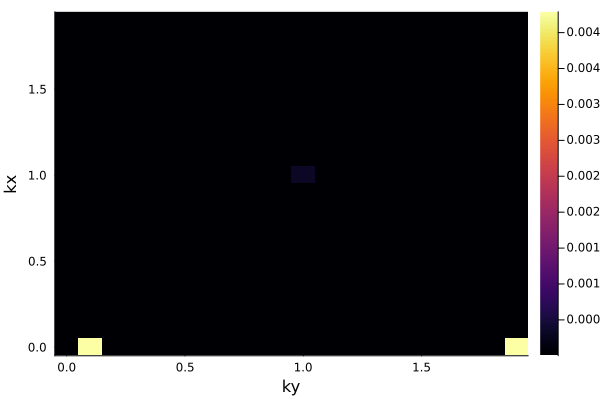

In [11]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [12]:
sort(vec(abs.(Fourier_mode_x)))

400-element Vector{Float64}:
 4.7915419211165175e-21
 2.3957709642102082e-20
 2.8011016091475603e-20
 2.8948210726873246e-20
 2.9302916663727236e-20
 3.054020723191113e-20
 3.436568649461672e-20
 3.488295180336631e-20
 4.285375049838502e-20
 4.404571324412791e-20
 ⋮
 2.0382167077329707e-13
 2.0382173932340188e-13
 2.481086066135696e-10
 2.4810860665490114e-10
 3.0499984898194827e-6
 3.049998489820094e-6
 0.00030891602248631815
 0.004789702787319785
 0.0047897027873197865

In [13]:
findmax(abs.(Fourier_mode_x))

(0.0047897027873197865, CartesianIndex(1, 20))

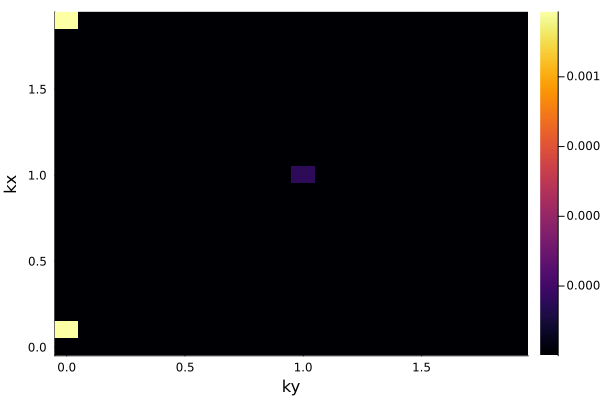

In [14]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [15]:
findmax(abs.(Fourier_mode_y))

(0.0012329437404958162, CartesianIndex(2, 1))

In [16]:
Fourier_mode_y[8,14]

-1.3192538153485728e-19 + 2.143658402288751e-19im

In [17]:
Fourier_mode_x[8,14]

-2.710505431213761e-19 + 4.25765445516925e-19im

In [18]:
Fourier_mode_y[14,8]

-9.190307477709159e-20 - 1.2026511349577692e-19im

In [19]:
Fourier_mode_x[14,8]

-1.2468324983583301e-18 - 2.6541343944258407e-19im

In [20]:
Fourier_mode_y[8,8]

8.216219588366713e-20 + 3.842319596359312e-21im

In [21]:
Fourier_mode_x[8,8]

-3.1848438816761693e-19 - 6.326839905811777e-19im